# rsfMRI — Parcel-level FC → Per-network Segregation & Integration

**Method:** For each subject and session:
1. Compute parcel-level Pearson FC and apply Fisher z-transform
2. Restrict to **cortical parcels (Yeo 1–7)** → ~200×200 matrix
3. For each network k:
   - **Segregation** (within-network FC): mean Fisher-z over all parcel pairs *inside* network k (diagonal excluded)
   - **Integration** (between-network FC): mean Fisher-z between parcels in network k and parcels in all *other* networks

Output shape: **subjects × sessions × 7 networks**

In [1]:
import os
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
plt.rcParams['axes.grid'] = False

## 1) Load data & labels

In [2]:
DATA_DIR = "../../../Data/"

# Load subject time series
data_all = {}
for file in glob.glob(os.path.join(DATA_DIR, "*/rsfMRI/*_TC_Schaefer.pkl")):
    subj_id = os.path.basename(file).split("_")[0]
    with open(file, "rb") as f:
        data_all[subj_id] = pickle.load(f)
print(f"Loaded {len(data_all)} subjects")

# Load Yeo7 labels
with open(os.path.join(DATA_DIR, "rsfMRI_utils.pkl"), "rb") as f:
    rsfMRI_utils = pickle.load(f)

yeo_info   = rsfMRI_utils["yeo7"][200]
yeo_rois   = np.array(yeo_info["yeoROIs"]).astype(int).ravel()  # length 219, labels 1..9
print(f"Yeo label length: {len(yeo_rois)}, unique: {np.unique(yeo_rois)}")

Loaded 20 subjects
Yeo label length: 219, unique: [1 2 3 4 5 6 7 8 9]


In [3]:
NETWORK_NAMES = [
    "Visual",
    "Somatomotor",
    "Dorsal Attention",
    "Ventral Attention",
    "Limbic",
    "Frontoparietal",
    "Default Mode",
]

K          = 7
NET_IDS    = np.arange(1, K + 1)

# Cortical mask: keep Yeo networks 1–7, drop 8 & 9 (subcortical)
cortical_mask = yeo_rois <= 7
labels        = yeo_rois[cortical_mask].astype(int)   # length ~200
N_CX          = labels.size
print(f"Cortical parcels: {N_CX}")

# Membership matrix M: (N_CX, 7) — M[i,k]=1 iff parcel i belongs to network k+1
M = (labels[:, None] == NET_IDS[None, :]).astype(float)

# Session axis: 15 sessions, _200 volume
SESSIONS = [f"V{str(k).zfill(2)}_200" for k in range(1, 16)]
x15      = np.arange(1, 16)

subjs = sorted(data_all.keys())
n_subj = len(subjs)
n_sess = len(SESSIONS)

Cortical parcels: 200


## 2) Compute per-network segregation & integration

For each subject × session:
- Pearson FC on cortical parcels → Fisher z (diagonal → NaN)
- **`seg_fc[i,j,k]`** = mean Fisher-z among parcel pairs *within* network k (upper-triangle only)
- **`int_fc[i,j,k]`** = mean Fisher-z between parcels of network k and all *other* parcels

Both arrays have shape **(n_subj, n_sess, 7)**.

In [4]:
seg_fc = np.full((n_subj, n_sess, K), np.nan)   # within-network
int_fc = np.full((n_subj, n_sess, K), np.nan)   # between-network

for i, subj in enumerate(subjs):
    for j, sess in enumerate(SESSIONS):
        if sess not in data_all[subj]:
            continue

        # --- parcel FC on cortical parcels only ---
        ts = data_all[subj][sess][:, cortical_mask]   # (T, N_CX)
        fc = np.corrcoef(ts.T)                         # (N_CX, N_CX)

        # Fisher z-transform; diagonal → NaN
        with np.errstate(divide='ignore', invalid='ignore'):
            fc_z = np.arctanh(fc)
        np.fill_diagonal(fc_z, np.nan)

        # Replace NaN with 0 for matrix multiply; track valid counts
        W   = np.where(np.isnan(fc_z), 0.0, fc_z)    # (N_CX, N_CX)
        Cnt = (~np.isnan(fc_z)).astype(float)         # (N_CX, N_CX)

        # Aggregate into network-pair sums and counts via M
        S   = M.T @ W   @ M    # (7, 7) sums of Fisher-z values
        Cmat = M.T @ Cnt @ M   # (7, 7) counts of valid pairs

        for k in range(K):
            # Within-network: diagonal block, but only upper-triangle pairs
            # S[k,k] includes both (i,j) and (j,i) — divide count by 2
            w_sum = S[k, k]
            w_cnt = Cmat[k, k]   # symmetric: already counts both directions
            seg_fc[i, j, k] = w_sum / w_cnt if w_cnt > 0 else np.nan

            # Between-network: row k, all columns except k
            b_sum = S[k, :].sum() - S[k, k]
            b_cnt = Cmat[k, :].sum() - Cmat[k, k]
            int_fc[i, j, k] = b_sum / b_cnt if b_cnt > 0 else np.nan

print("seg_fc shape:", seg_fc.shape)
print("int_fc shape:", int_fc.shape)

seg_fc shape: (20, 15, 7)
int_fc shape: (20, 15, 7)


## 3) Visualise — per-network trajectories over sessions

Each subplot: group mean ± SD (shaded) with SEM error bars.

In [5]:
def plot_per_network(metric_3d, title, ylabel, network_names=NETWORK_NAMES, x=x15):
    """metric_3d: (subjects, sessions, 7)"""
    K   = metric_3d.shape[2]
    fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True)
    axes = axes.ravel()

    for k in range(K):
        ax   = axes[k]
        y    = metric_3d[:, :, k]               # (subjects, sessions)
        mean = np.nanmean(y, axis=0)
        sd   = np.nanstd(y, axis=0)
        n    = np.sum(~np.isnan(y), axis=0)
        sem  = np.divide(sd, np.sqrt(n),
                         out=np.full_like(sd, np.nan, dtype=float),
                         where=n > 0)

        ax.fill_between(x, mean - sd, mean + sd, alpha=0.2)
        ax.plot(x, mean, marker="o", linewidth=2)
        ax.errorbar(x, mean, yerr=sem, fmt="none", capsize=3)
        ax.set_title(network_names[k])
        ax.set_ylabel(ylabel)
        ax.set_xticks(x)

    axes[K].axis("off")   # hide 8th panel
    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    plt.show()

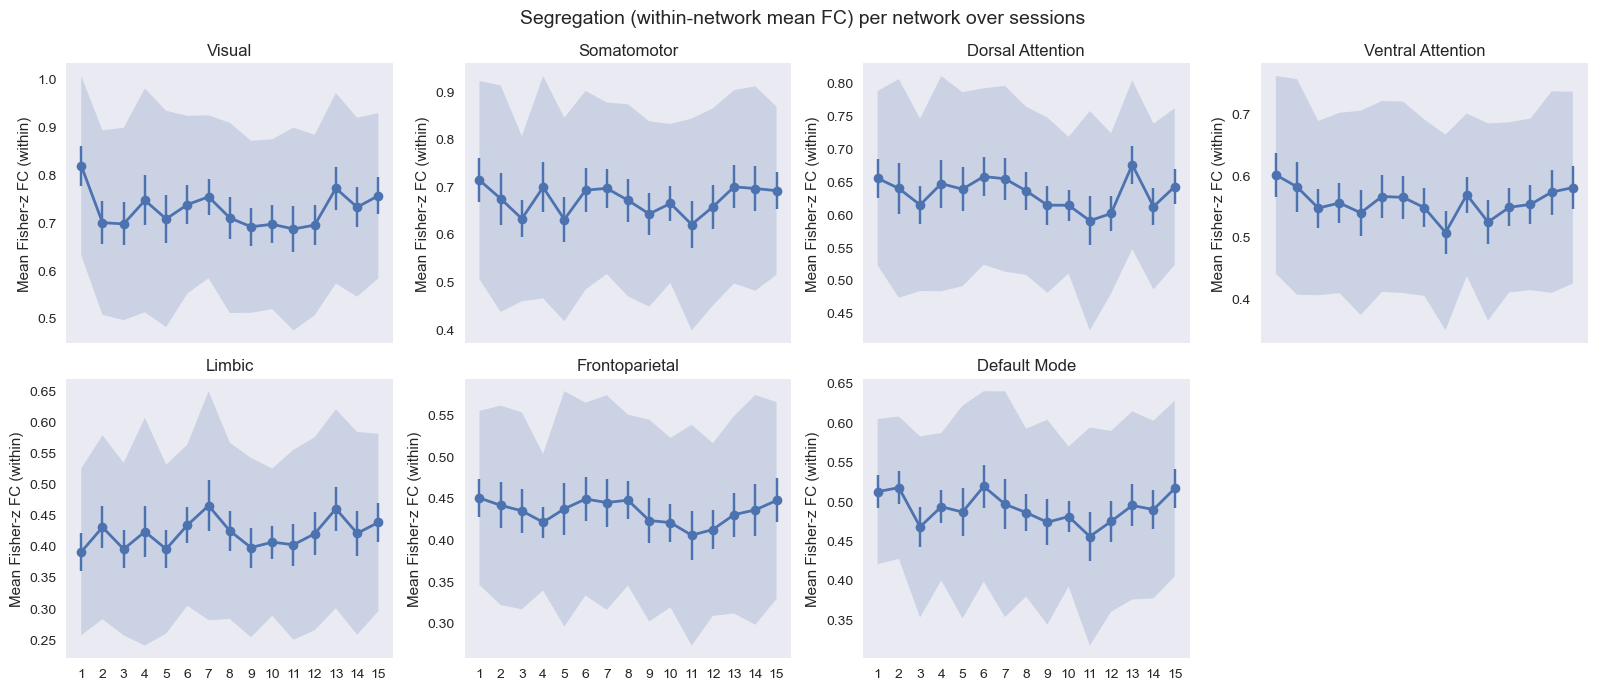

In [6]:
plot_per_network(
    seg_fc,
    title="Segregation (within-network mean FC) per network over sessions",
    ylabel="Mean Fisher-z FC (within)",
)

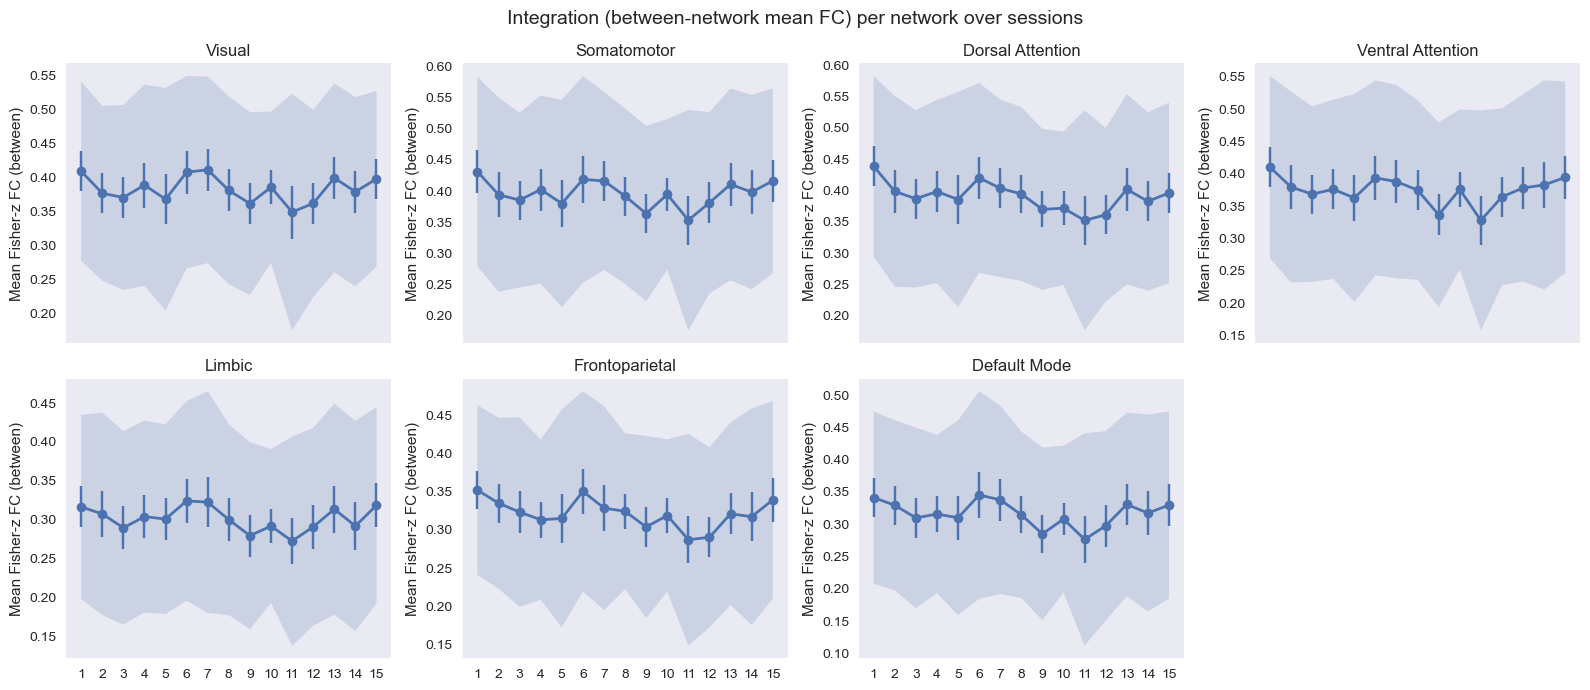

In [7]:
plot_per_network(
    int_fc,
    title="Integration (between-network mean FC) per network over sessions",
    ylabel="Mean Fisher-z FC (between)",
)